# Part 1 - Wind Forecast Data Analysis

We will be using `error = actual − forecast`

- Positive value for error means more wind than expected
- Negative value for error means less wind than expected
- Zero value means forecast as expected

In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#f8f9fa',
    'axes.facecolor':   '#f0f2f5',
    'axes.grid':        True,
    'grid.color':       '#e2e8f0',
    'font.family':      'sans-serif',
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.labelsize':   11,
})

BLUE   = '#4a90d9'
GREEN  = '#48bb78'
RED    = '#e07a5f'
PURPLE = '#9f7aea'
GREY   = '#718096'

print('Ready')

Ready ✓


## 1. Importing the data

In [2]:
BASE = 'https://data.elexon.co.uk/bmrs/api/v1/datasets'

print('Downloading actual generation data...')
r = requests.get(f'{BASE}/FUELHH/stream', params={
    'publishDateTimeFrom': '2024-01-01T00:00:00Z',
    'publishDateTimeTo':   '2024-01-31T23:59:59Z',
    'fuelType': 'WIND',
}, timeout=60)
actuals_raw = r.json()
print(f'  Got {len(actuals_raw)} records')

print('Downloading forecast data...')
r = requests.get(f'{BASE}/WINDFOR/stream', params={
    'publishDateTimeFrom': '2023-12-30T00:00:00Z',
    'publishDateTimeTo':   '2024-01-31T23:59:59Z',
}, timeout=60)
forecasts_raw = r.json()
print(f'  Got {len(forecasts_raw)} records')

  Got 1488 records
  Got 12936 records


## 2. Cleaning and setting up data for use

We're starting from 31st December 2023 as we need forecast data from 4 hours prior for 1st January 2024

In [ ]:
# Build actuals dataframe
act = pd.DataFrame(actuals_raw)[['startTime', 'generation']]
act['startTime'] = pd.to_datetime(act['startTime'], utc=True).dt.round('30min')
act = act.rename(columns={'startTime': 'time', 'generation': 'actual'})
act = act.drop_duplicates('time').sort_values('time').reset_index(drop=True)

# Build forecasts dataframe
fct = pd.DataFrame(forecasts_raw)[['startTime', 'publishTime', 'generation']]
fct['startTime']   = pd.to_datetime(fct['startTime'],   utc=True).dt.round('30min')
fct['publishTime'] = pd.to_datetime(fct['publishTime'], utc=True)
fct = fct.rename(columns={'startTime': 'time', 'generation': 'forecast'})

# For each actual, find the best forecast made at least 4 hours before
# (latest publish time that is still 4+ hours before the target)
HORIZON = 4  # hours
fct_grouped = fct.groupby('time')
rows = []
for _, row in act.iterrows():
    t = row['time']
    cutoff = t - pd.Timedelta(hours=HORIZON)
    # WINDFOR is hourly so try nearest hour if exact match not found
    for key in [t, t.round('h')]:
        if key in fct_grouped.groups:
            cands = fct_grouped.get_group(key)
            valid = cands[cands['publishTime'] <= cutoff]
            if not valid.empty:
                best = valid.loc[valid['publishTime'].idxmax(), 'forecast']
                rows.append({'time': t, 'actual': row['actual'], 'forecast': best})
                break

df = pd.DataFrame(rows)
df['error'] = df['actual'] - df['forecast']
df['hour']  = df['time'].dt.hour
df['day']   = df['time'].dt.day

print(f'Matched {len(df)} time slots with both actual and forecast values')
df.head(4)

Matched 1488 time slots with both actual and forecast values


,time,actual,forecast,error,hour,day
0,2023-12-31 23:30:00+00:00,9980,11453,-1473,23,31
1,2024-01-01 00:00:00+00:00,10402,11453,-1051,0,1
2,2024-01-01 00:30:00+00:00,10845,11453,-608,0,1
3,2024-01-01 01:00:00+00:00,11218,11841,-623,1,1


## Analysis 1 — Basic Error Stats

- **Mean error** — the average mistake (if the forecast leans too high or too low)
- **Typical error (MAE)** — the average size of the mistake, ignoring direction (absolute value of error)
- **P99 error** — the worst-case mistake that happens 1% of the time

In [22]:
mean_err   = df['error'].mean()
mae        = df['error'].abs().mean()
p99        = df['error'].quantile(0.99)
p01        = df['error'].quantile(0.01)
pct_within_500  = (df['error'].abs() < 500).mean()  * 100
pct_within_1000 = (df['error'].abs() < 1000).mean() * 100

print(f'  Average mistake (bias):    {mean_err:+.0f} MW')
print(f'  Typical mistake (MAE):      {mae:.0f} MW')
print(f'  Worst 1% of errors (P99):  {p99:+.0f} MW')
print(f'  Worst 1% low errors (P01): {p01:+.0f} MW')
print('')
print(f'  Within 500 MW:  {pct_within_500:.0f}% of the time')
print(f'  Within 1000 MW: {pct_within_1000:.0f}% of the time')
print('')

direction = 'under-predicted (actual > forecast)' if mean_err > 0 else 'over-predicted (forecast > actual)'
print(f'\n- On average, the forecast {direction} by {abs(mean_err):.0f} MW')
print(f'- In the worst 1% of cases, errors can exceed {max(abs(p99), abs(p01)):.0f} MW')

  Average mistake (bias):    -1183 MW
  Typical mistake (MAE):      1842 MW
  Worst 1% of errors (P99):  +2951 MW
  Worst 1% low errors (P01): -6347 MW

  Within 500 MW:  22% of the time
  Within 1000 MW: 38% of the time


- On average, the forecast over-predicted (forecast > actual) by 1183 MW
- In the worst 1% of cases, errors can exceed 6347 MW


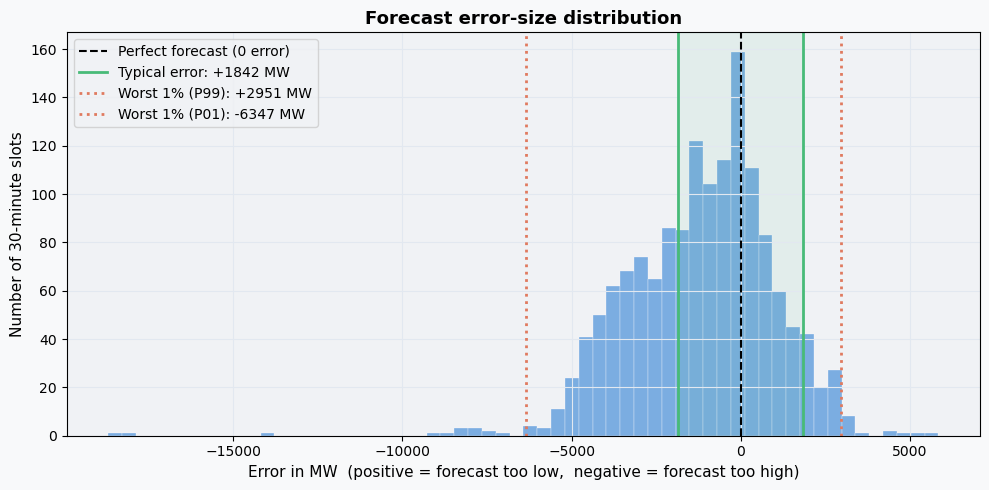

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df['error'], bins=60, color=BLUE, alpha=0.7, edgecolor='white', linewidth=0.3)

ax.axvline(0,    color='black',  linewidth=1.5, linestyle='--', label='Perfect forecast (0 error)')
ax.axvline(mae,  color=GREEN,    linewidth=2,   linestyle='-',  label=f'Typical error: +{mae:.0f} MW')
ax.axvline(-mae, color=GREEN,    linewidth=2,   linestyle='-')
ax.axvline(p99,  color=RED,      linewidth=2,   linestyle=':',  label=f'Worst 1% (P99): +{p99:.0f} MW')
ax.axvline(p01,  color=RED,      linewidth=2,   linestyle=':',  label=f'Worst 1% (P01): {p01:.0f} MW')

ax.set_xlabel('Error in MW  (positive = forecast too low,  negative = forecast too high)', fontsize=11)
ax.set_ylabel('Number of 30-minute slots', fontsize=11)
ax.set_title('Forecast error-size distribution')
ax.legend(fontsize=10)

# Shade the typical error region
ax.axvspan(-mae, mae, alpha=0.08, color=GREEN, label='Typical range')

plt.tight_layout()
plt.savefig('fig1_overall_errors.png', dpi=150, bbox_inches='tight')
plt.show()

**What this chart shows:** Each bar is a bucket of error sizes. The tall bars in the middle mean the forecast is usually close to correct. The long tails on each side are the rare but large mistakes.

- Green lines show typical error range. Most errors fall in this area.
- Red lines show rarer worst case errors — only 1% of predictions are this far off (on either side)

## Analysis 2 — Variation of forecast error throughout the day

From a short glance, forecast errors are greater closer to the evenings and night. This is likely due changes in the atmosphere.

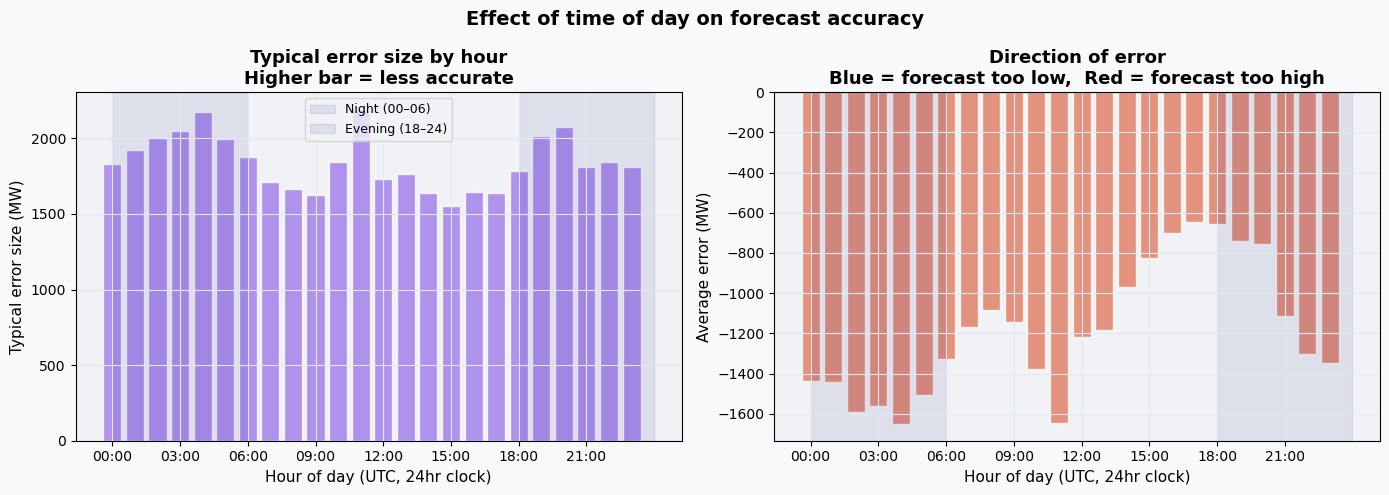

In [77]:
hourly = df.groupby('hour').agg(
    mean_error = ('error', 'mean'),
    mae        = ('error', lambda x: x.abs().mean()),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Effect of time of day on forecast accuracy', fontsize=14, fontweight='bold')

# Left: typical error size (MAE) by hour
ax = axes[0]
ax.bar(hourly['hour'], hourly['mae'], color=PURPLE, alpha=0.8, edgecolor='white')
ax.set_xlabel('Hour of day (UTC, 24hr clock)')
ax.set_ylabel('Typical error size (MW)')
ax.set_title('Typical error size by hour\nHigher bar = less accurate')
ax.set_xticks(range(0, 24, 3))
ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 3)])

# Shade night hours
ax.axvspan(0,  6,  alpha=0.08, color='navy', label='Night (00–06)')
ax.axvspan(18, 24, alpha=0.08, color='navy', label='Evening (18–24)')
ax.legend(fontsize=9)

# Right: bias (direction of error) by hour
ax2 = axes[1]
colors = [RED if v < 0 else BLUE for v in hourly['mean_error']]
ax2.bar(hourly['hour'], hourly['mean_error'], color=colors, alpha=0.8, edgecolor='white')
ax2.axhline(0, color='black', linewidth=1.5)
ax2.set_xlabel('Hour of day (UTC, 24hr clock)')
ax2.set_ylabel('Average error (MW)')
ax2.set_title('Direction of error\nBlue = forecast too low,  Red = forecast too high')
ax2.set_xticks(range(0, 24, 3))
ax2.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 3)])

ax2.axvspan(0,  6,  alpha=0.08, color='navy')
ax2.axvspan(18, 24, alpha=0.08, color='navy')

plt.tight_layout()
plt.savefig('fig2_error_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

**What this shows:**

- The left chart shows how big the errors (absolute) are at each hour. Taller bar = less accurate predictions at that time
- The right chart shows the direction of the error. Blue bars mean the forecast predicted too little wind (actual was higher). Red bars mean the forecast predicted too much wind.

The shaded areas represent night and evening hours, where we expect to see larger errors likely due to changing atmospheric conditions after sunset.

Conclusion:
- From the left chart, we can see that forecasts are less accurate in the evening hours, possibly due to changes in atmospheric conditions.
- From the right chart interestingly, we can see that the forecast seems to over-predict consistently. This explains why all the bars in the graph are red.

## Analysis 3 — Effect of increased wind generation on forecast accuracy

Checking if forecast errors larger during high-wind periods. During storms, it can be hard to forecast exactly how strong the wind will be. Errors could be greater at high wind generation levels.

In [39]:
# Split generation into 5 equal groups from lowest to highest
df['gen_level'] = pd.qcut(
    df['actual'],
    q=5,
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)

level_stats = df.groupby('gen_level', observed=True).agg(
    avg_actual   = ('actual', 'mean'),
    typical_error= ('error',  lambda x: x.abs().mean()),
    avg_error    = ('error',  'mean')
).reset_index()

print('Average generation and error size by wind level:')
print(level_stats[['gen_level', 'avg_actual', 'typical_error', 'avg_error']]
      .rename(columns={
          'gen_level':     'Wind Level',
          'avg_actual':    'Avg Generation (MW)',
          'typical_error': 'Typical Error (MW)',
          'avg_error':     'Avg Error (MW)'
      }).to_string(index=False, float_format='{:.0f}'.format))

Average generation and error size by wind level:
Wind Level  Avg Generation (MW)  Typical Error (MW)  Avg Error (MW)
  Very Low                 4922                1022            -607
       Low                 7140                1043            -425
    Medium                 9800                1811            -606
      High                12458                2467           -1526
 Very High                14908                2866           -2751


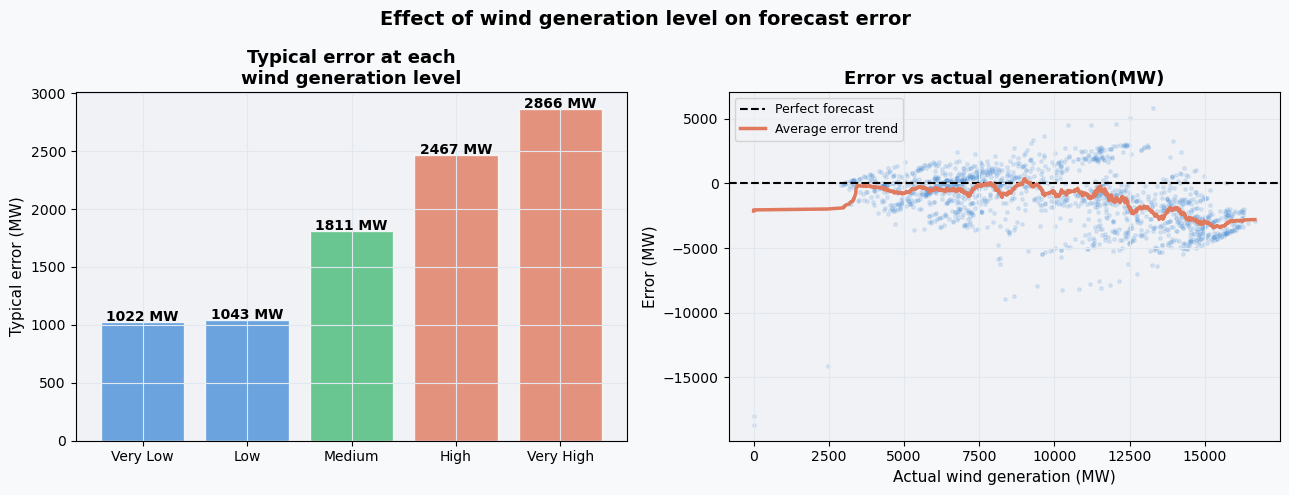

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Effect of wind generation level on forecast error', fontsize=14, fontweight='bold')

levels = level_stats['gen_level'].astype(str)
x = range(len(levels))
bar_colors = [BLUE, BLUE, GREEN, RED, RED]

# Left: typical error by wind level
ax = axes[0]
bars = ax.bar(x, level_stats['typical_error'], color=bar_colors, alpha=0.8, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(levels, fontsize=10)
ax.set_ylabel('Typical error (MW)')
ax.set_title('Typical error at each\nwind generation level')
for bar, val in zip(bars, level_stats['typical_error']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            f'{val:.0f} MW', ha='center', fontsize=10, fontweight='bold')

# Right: scatter of error vs actual generation
ax2 = axes[1]
ax2.scatter(df['actual'], df['error'], alpha=0.15, s=6, color=BLUE)
ax2.axhline(0, color='black', linewidth=1.5, linestyle='--', label='Perfect forecast')
# Add a simple rolling average line
df_s = df.sort_values('actual')
roll = df_s['error'].rolling(50, center=True, min_periods=10).mean()
ax2.plot(df_s['actual'], roll, color=RED, linewidth=2.5, label='Average error trend')
ax2.set_xlabel('Actual wind generation (MW)')
ax2.set_ylabel('Error (MW)')
ax2.set_title('Error vs actual generation(MW)')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig3_error_vs_generation.png', dpi=150, bbox_inches='tight')
plt.show()

Conclusions:

- The bar chart groups all 30-minute slots into five wind levels and shows the typical error at each level. If the bars get taller from left to right, errors grow with generation
- The scatter plot shows every single data point. Each dot is one 30-minute slot. The more the dots spread out vertically at high generation values (right side), the less accurate the forecast is during high-wind periods
- The red trend line shows whether errors are positive or negative at each generation level. Wind generation errors grow with increasing generation
- The steady line at the beginning shows that there is not enough data to draw conclusions. Therefore, we can only start from the point where the data is sufficient.

## Analysis 4 — Trend of increasing errors towards the end of January

From searching online, January 2024 had a notable storm event: Storm Jocelyn struck the UK around 23–24 January. This could explain the increase in errors towards the end of January.

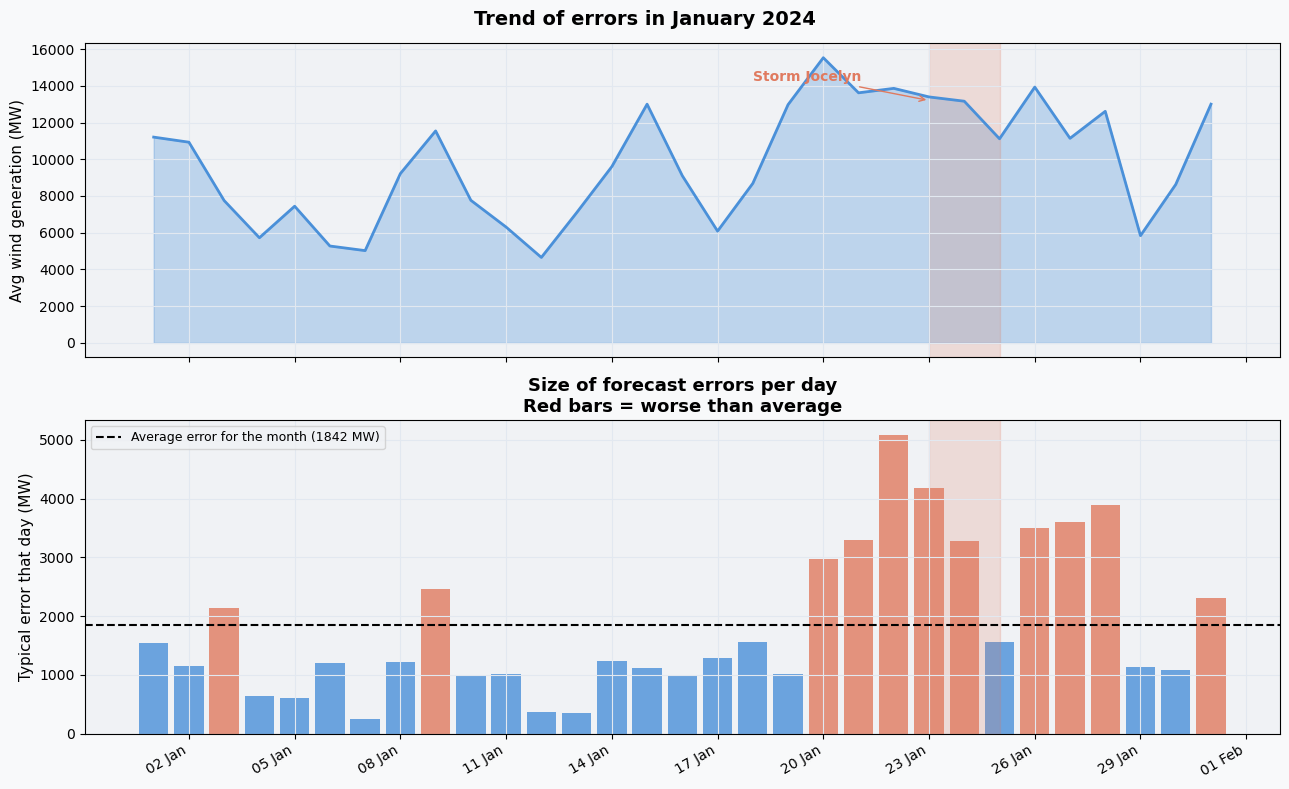

In [44]:
import matplotlib.dates as mdates

daily = df.groupby('day').agg(
    avg_actual    = ('actual', 'mean'),
    typical_error = ('error',  lambda x: x.abs().mean()),
    avg_error     = ('error',  'mean'),
).reset_index()
daily['date'] = pd.to_datetime('2024-01-' + daily['day'].astype(str).str.zfill(2), utc=True)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
fig.suptitle('Trend of errors in January 2024', fontsize=14, fontweight='bold')

# Top: actual generation each day
ax = axes[0]
ax.fill_between(daily['date'], daily['avg_actual'], alpha=0.3, color=BLUE)
ax.plot(daily['date'], daily['avg_actual'], color=BLUE, linewidth=2)
ax.set_ylabel('Avg wind generation (MW)')

# Annotate storm
storm = pd.Timestamp('2024-01-23', tz='UTC')
ax.axvspan(storm, storm + pd.Timedelta(days=2), alpha=0.2, color=RED)
ax.annotate('Storm Jocelyn', xy=(storm, daily['avg_actual'].max() * 0.85),
            fontsize=10, color=RED, fontweight='bold',
            xytext=(storm - pd.Timedelta(days=5), daily['avg_actual'].max() * 0.92),
            arrowprops=dict(arrowstyle='->', color=RED))

# Bottom: daily typical error
ax2 = axes[1]
bar_colors = [RED if e > daily['typical_error'].mean() else BLUE for e in daily['typical_error']]
ax2.bar(daily['date'], daily['typical_error'], color=bar_colors, alpha=0.8,
        width=pd.Timedelta(hours=20))
ax2.axhline(daily['typical_error'].mean(), color='black', linewidth=1.5,
            linestyle='--', label=f'Average error for the month ({daily["typical_error"].mean():.0f} MW)')
ax2.set_ylabel('Typical error that day (MW)')
ax2.set_title('Size of forecast errors per day\nRed bars = worse than average')
ax2.legend(fontsize=9)

ax2.axvspan(storm, storm + pd.Timedelta(days=2), alpha=0.2, color=RED)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax2.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.savefig('fig4_errors_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

Conclusions:

- The top chart shows that there was a peak in generation towards the end of the month
- However, the bottom chart shows the typical forecast error for each day. Red bars are days where the error was worse than the monthly average
- It is observed that the forecast error was worse than average towards the end of the month, which matches the trend of increasing generation in the above chart

## Summary

Data obtained from the above 4 analyses:

In [33]:
worst_hour  = hourly.loc[hourly['mae'].idxmax(), 'hour']
best_hour   = hourly.loc[hourly['mae'].idxmin(), 'hour']
worst_level = level_stats.loc[level_stats['typical_error'].idxmax(), 'gen_level']

print(f'  1. Overall Accuracy')
print(f'     Typical error:      {mae:.0f} MW')
print(f'     Worst 1% of errors: {max(abs(p99), abs(p01)):.0f} MW')
print(f'     Direction of bias:  {"under-forecasts (too low)" if mean_err > 0 else "over-forecasts (too high)"}')
print()
print(f'  2. Time of Day')
print(f'     Least accurate hour: {worst_hour:02d}:00')
print(f'     Most accurate hour:  {best_hour:02d}:00')
print()
print(f'  3. Generation Level')
print(f'     Errors are largest during: {worst_level} wind generation')
print(f'     This is when forecasting is hardest (storm events)')
print()
print(f'  4. Time Variation')
print(f'     Storm Jocelyn (23-24 Jan) likely caused a spike in errors')
print(f'     Errors are not uniform as bad weather = bad forecasts')

  1. Overall Accuracy
     Typical error:      1842 MW
     Worst 1% of errors: 6347 MW
     Direction of bias:  over-forecasts (too high)

  2. Time of Day
     Least accurate hour: 11:00
     Most accurate hour:  15:00

  3. Generation Level
     Errors are largest during: Very High wind generation
     This is when forecasting is hardest (storm events)

  4. Time Variation
     Storm Jocelyn (23-24 Jan) likely caused a spike in errors
     Errors are not uniform as bad weather = bad forecasts


# Part 2 — Reliability Estimation

We want to find out how many MW of wind power can the UK grid reliably expect to be available.

**Disadvantages of using maximum or average**

- Most of the time, the wind cannot reliably generate anywhere close to the maximum amount, due to lulls in weather, or storms.
- The average is also unreliable, from glancing at the data, half the time wind is below average.

**Chosen approach: use the 95% floor (The amount that the wind can generate 95% of the time, always.)**

We find the MW level that wind generates almost always meets or exceeds this value 95% of the time. This means we are only in trouble 5% of the time (about 36 hours in a month). We can call this the P5 value.

We will use 4  different approaches to check if this value is a reliable metric for expected reliable wind generation.

## Approach 1 — Level of power generation 95% of the time

We look at every single 30-minute reading in January 2024 and find the MW level that wind met or exceeded 95% of the time.

In [48]:
# act is already loaded from Part 1 above
# If running standalone, re-run the data steps first

p5_overall   = act['actual'].quantile(0.05)
p50_overall  = act['actual'].quantile(0.50)
p95_overall  = act['actual'].quantile(0.95)
mean_overall = act['actual'].mean()
max_overall  = act['actual'].max()
min_overall  = act['actual'].min()

print('Wind Generation in January 2024')
print('')
print(f'  Minimum ever recorded:     {min_overall:,.0f} MW')
print(f'  95% floor (P5):            {p5_overall:,.0f} MW  Amount that can be expected reliably (95% of the time)')
print(f'  Typical amount (median):   {p50_overall:,.0f} MW')
print(f'  Average:                   {mean_overall:,.0f} MW')
print(f'  Top 5% (P95):              {p95_overall:,.0f} MW')
print(f'  Maximum ever recorded:     {max_overall:,.0f} MW')
print('')
print(f'Wind exceeded {p5_overall:,.0f} MW in 95% of all 30-min slots in January 2024')


Wind Generation in January 2024

  Minimum ever recorded:     0 MW
  95% floor (P5):            4,301 MW  Amount that can be expected reliably (95% of the time)
  Typical amount (median):   9,864 MW
  Average:                   9,846 MW
  Top 5% (P95):              15,425 MW
  Maximum ever recorded:     16,662 MW

Wind exceeded 4,301 MW in 95% of all 30-min slots in January 2024


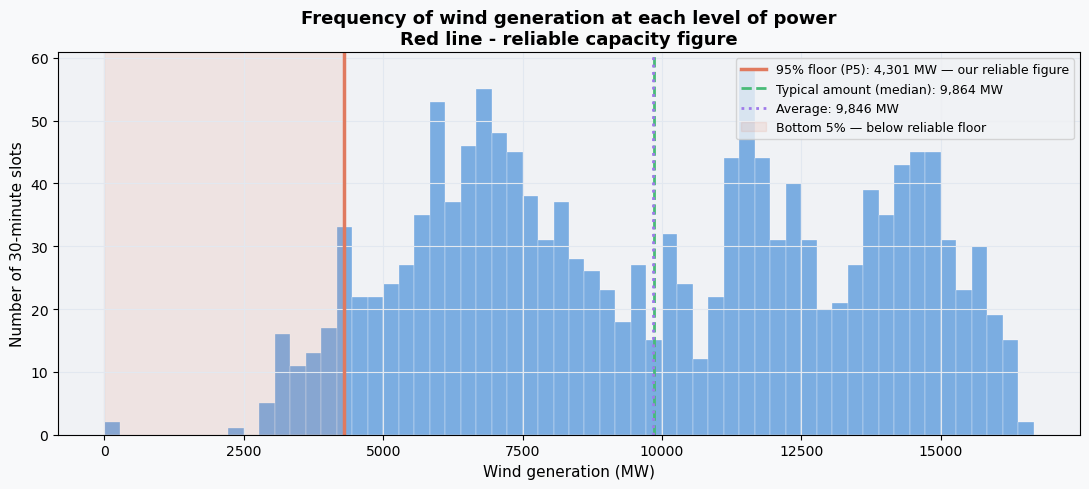

In [50]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.hist(act['actual'], bins=60, color=BLUE, alpha=0.7, edgecolor='white', linewidth=0.3)
ax.axvline(p5_overall,   color=RED,    linewidth=2.5, linestyle='-',
           label=f'95% floor (P5): {p5_overall:,.0f} MW — our reliable figure')
ax.axvline(p50_overall,  color=GREEN,  linewidth=2,   linestyle='--',
           label=f'Typical amount (median): {p50_overall:,.0f} MW')
ax.axvline(mean_overall, color=PURPLE, linewidth=2,   linestyle=':',
           label=f'Average: {mean_overall:,.0f} MW')
ax.axvspan(min_overall, p5_overall, alpha=0.12, color=RED, label='Bottom 5% — below reliable floor')

ax.set_xlabel('Wind generation (MW)', fontsize=11)
ax.set_ylabel('Number of 30-minute slots', fontsize=11)
ax.set_title('Frequency of wind generation at each level of power\nRed line - reliable capacity figure')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig5_reliability_overall.png', dpi=150, bbox_inches='tight')
plt.show()


Conclusion:

Each bar is how many 30-minute slots had that level of wind. The red line is our reliable capacity — everything to its left is the 5% of times wind fell below it. The gap between the red line and the green/purple lines shows how much we are giving up by being conservative.

## Approach 2 — Checking reliability during peak hours

People use the most electricity in the evening (17:00–20:00) when people get home and cook dinner. This is when the grid needs wind the most. We check whether wind is as reliable during those specific hours.

In [52]:
act['hour'] = act['time'].dt.hour

peak     = act[act['hour'].between(17, 20)]
off_peak = act[~act['hour'].between(17, 20)]

p5_peak    = peak['actual'].quantile(0.05)
p5_offpeak = off_peak['actual'].quantile(0.05)

print('')
print('  Capacity by Time of Day:')
print('')
print(f'  All hours (P5):              {p5_overall:,.0f} MW')
print(f'  Peak hours 17-20:00 (P5):    {p5_peak:,.0f} MW')
print(f'  Off-peak hours (P5):         {p5_offpeak:,.0f} MW')
print('')
diff = p5_overall - p5_peak
if diff > 0:
    print(f'Wind is {diff:,.0f} MW LESS reliable during peak demand hours.')
    print(f'Use the peak-hour figure for planning: {p5_peak:,.0f} MW')
else:
    print(f'Wind is actually more reliable during peak hours.')
    print(f'Peak hour reliable capacity: {p5_peak:,.0f} MW')



  Capacity by Time of Day:

  All hours (P5):              4,301 MW
  Peak hours 17-20:00 (P5):    4,424 MW
  Off-peak hours (P5):         4,252 MW

Wind is actually more reliable during peak hours.
Peak hour reliable capacity: 4,424 MW


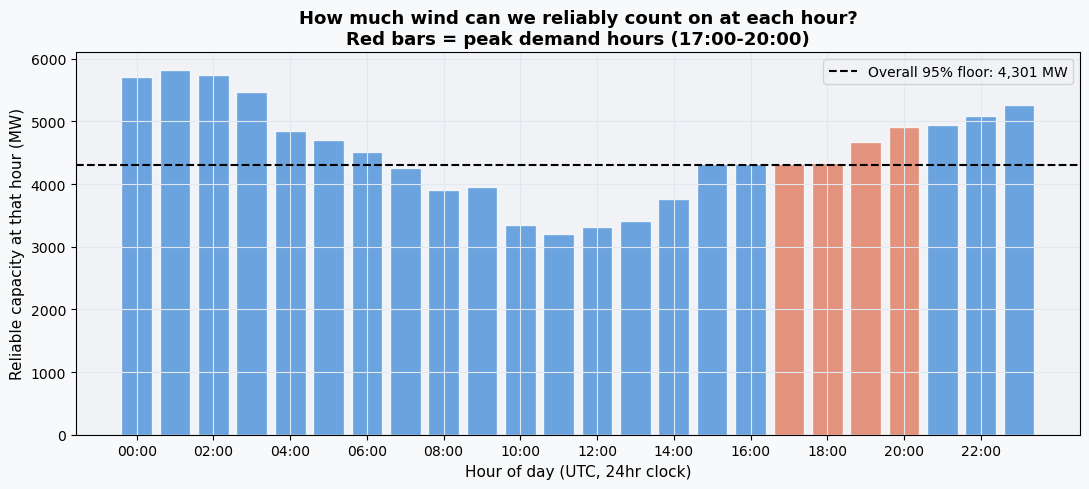

Taller bar = more reliable wind at that hour of day


In [53]:
hourly_p5 = act.groupby('hour')['actual'].quantile(0.05).reset_index()
hourly_p5.columns = ['hour', 'p5']

fig, ax = plt.subplots(figsize=(11, 5))
bar_colors = [RED if h in range(17, 21) else BLUE for h in hourly_p5['hour']]
ax.bar(hourly_p5['hour'], hourly_p5['p5'], color=bar_colors, alpha=0.8, edgecolor='white')
ax.axhline(p5_overall, color='black', linewidth=1.5, linestyle='--',
           label=f'Overall 95% floor: {p5_overall:,.0f} MW')
ax.set_xlabel('Hour of day (UTC, 24hr clock)', fontsize=11)
ax.set_ylabel('Reliable capacity at that hour (MW)', fontsize=11)
ax.set_title('How much wind can we reliably count on at each hour?\nRed bars = peak demand hours (17:00-20:00)')
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)])
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fig6_reliability_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()
print('Taller bar = more reliable wind at that hour of day')


**What this shows:**

Each bar is the 95% floor for that specific hour. Taller bars mean more reliably available wind. Red bars are the critical evening hours. If they are shorter than the others, wind is less dependable exactly when it is needed most.

Conclusion:

During high demand periods, the capacity generated is equal to, or more than the 95% reliable floor of generation. This means that even after accounting for reliable generation, there is capacity left in reserve during peak hours.

## Approach 3 — Longest period with low wind

Knowing the 95% floor is useful, but we also need to know when wind does fall below our reliable floor, how long does it last? A 2 hour gap can be managed. A 2 day gap can be an issue that needs to be addressed with backup solutions.

In [56]:
import matplotlib.dates as mdates

act_sorted = act.sort_values('time').reset_index(drop=True)
act_sorted['below_floor'] = act_sorted['actual'] < p5_overall
act_sorted['run_id'] = (act_sorted['below_floor'] != act_sorted['below_floor'].shift()).cumsum()

runs = act_sorted[act_sorted['below_floor']].groupby('run_id').agg(
    start   = ('time',   'min'),
    end     = ('time',   'max'),
    min_gen = ('actual', 'min'),
    slots   = ('actual', 'count'),
).reset_index(drop=True)
runs['duration_hours'] = runs['slots'] * 0.5
runs = runs.sort_values('duration_hours', ascending=False)

longest = runs.iloc[0]

print(f'Our 95% reliable floor: {p5_overall:,.0f} MW')
print(f'Number of times wind dropped below this in January: {len(runs)}')
print()
print('Top 5 longest low-wind periods:')
print('')
for _, row in runs.head(5).iterrows():
    print(f"  {row['start'].strftime('%d %b %H:%M')} to {row['end'].strftime('%d %b %H:%M')}"
          f"  |  {row['duration_hours']:.1f} hrs"
          f"  |  lowest: {row['min_gen']:,.0f} MW")
print('')
print(f"Longest low-wind period: {longest['duration_hours']:.1f} hours")
print(f"From {longest['start'].strftime('%d %b %H:%M')} to {longest['end'].strftime('%d %b %H:%M')}")
print(f"Lowest point during this period: {longest['min_gen']:,.0f} MW")


Our 95% reliable floor: 4,301 MW
Number of times wind dropped below this in January: 8

Top 5 longest low-wind periods:

  29 Jan 04:30 to 29 Jan 14:30  |  10.5 hrs  |  lowest: 2,918 MW
  12 Jan 07:30 to 12 Jan 15:00  |  8.0 hrs  |  lowest: 3,201 MW
  04 Jan 12:30 to 04 Jan 18:30  |  6.5 hrs  |  lowest: 2,988 MW
  07 Jan 18:30 to 07 Jan 23:30  |  5.5 hrs  |  lowest: 3,992 MW
  17 Jan 10:00 to 17 Jan 13:30  |  4.0 hrs  |  lowest: 3,179 MW

Longest low-wind period: 10.5 hours
From 29 Jan 04:30 to 29 Jan 14:30
Lowest point during this period: 2,918 MW


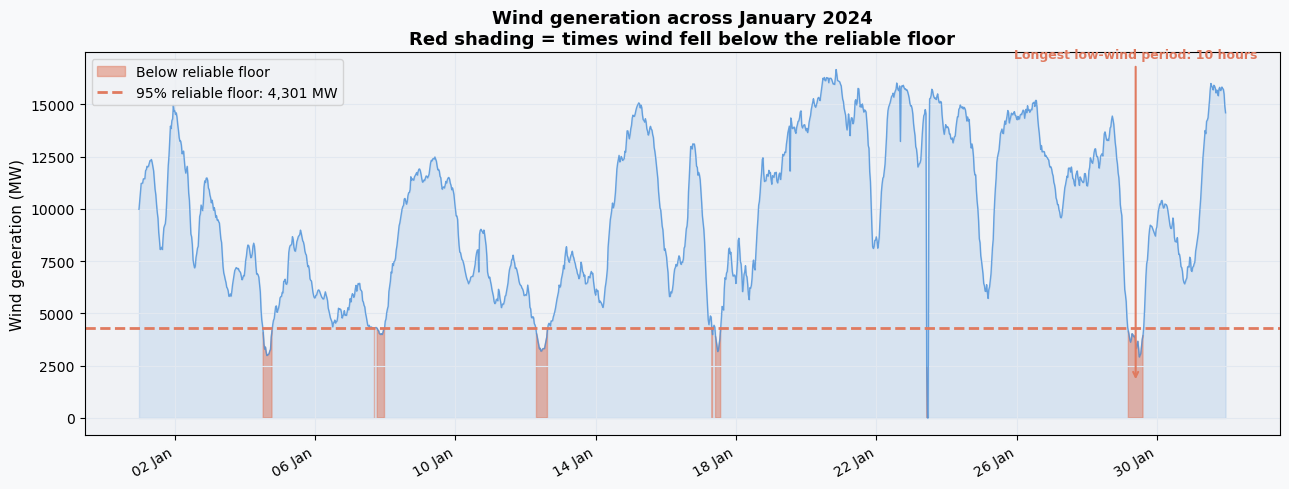

In [57]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(act_sorted['time'], act_sorted['actual'], color=BLUE, linewidth=1, alpha=0.8)
ax.fill_between(act_sorted['time'], act_sorted['actual'], alpha=0.15, color=BLUE)
ax.fill_between(act_sorted['time'], act_sorted['actual'],
                where=act_sorted['below_floor'],
                color=RED, alpha=0.5, label='Below reliable floor')
ax.axhline(p5_overall, color=RED, linewidth=2, linestyle='--',
           label=f'95% reliable floor: {p5_overall:,.0f} MW')

mid_time = longest['start'] + (longest['end'] - longest['start']) / 2
ax.annotate(f"Longest low-wind period: {longest['duration_hours']:.0f} hours",
            xy=(mid_time, p5_overall * 0.4),
            xytext=(mid_time, p5_overall * 4),
            fontsize=9, color=RED, fontweight='bold', ha='center',
            arrowprops=dict(arrowstyle='->', color=RED, lw=1.5))

ax.set_ylabel('Wind generation (MW)', fontsize=11)
ax.set_title('Wind generation across January 2024\nRed shading = times wind fell below the reliable floor')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=4))
plt.xticks(rotation=30, ha='right')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fig7_low_wind_periods.png', dpi=150, bbox_inches='tight')
plt.show()


**What this shows:**

The blue line is wind generation across the whole month. Every time it dips below the red dashed line (the reliable floor), it is shaded red. The longest red stretch is the worst case that we would need to plan backup capacity for.

## Approach 4 — Comparison to total UK electricity demand

The MW numbers only have meaning when we compare them to how much electricity the UK actually needs. According to a quick search, the UK typically uses around 35,000–40,000 MW at any given time. We can express our reliable capacity as a percentage of demand.

In [65]:
UK_TYPICAL_DEMAND = 37000  # MW — typical average UK demand
UK_PEAK_DEMAND    = 45000  # MW — typical winter evening peak

conservative = min(p5_overall, p5_peak)

print(f'  Typical UK demand: around {UK_TYPICAL_DEMAND:,} MW')
print()
print(f'  Recommended reliable floor:      {conservative:,.0f} MW  = {conservative/UK_TYPICAL_DEMAND*100:.1f}% of demand')
print(f'  All-hours P5:                    {p5_overall:,.0f} MW  = {p5_overall/UK_TYPICAL_DEMAND*100:.1f}% of demand')
print(f'  Peak-hours P5:                   {p5_peak:,.0f} MW  = {p5_peak/UK_PEAK_DEMAND*100:.1f}% of peak demand')
print(f'  Typical output (median):         {p50_overall:,.0f} MW  = {p50_overall/UK_TYPICAL_DEMAND*100:.1f}% of demand')
print(f'  Average output:                  {mean_overall:,.0f} MW  = {mean_overall/UK_TYPICAL_DEMAND*100:.1f}% of demand')
print('')
print(f'  Wind can reliably cover {conservative/UK_TYPICAL_DEMAND*100:.1f}% of UK electricity demand')
print(f'  On a typical day it covers around {p50_overall/UK_TYPICAL_DEMAND*100:.1f}%')


  Typical UK demand: around 37,000 MW

  Recommended reliable floor:      4,301 MW  = 11.6% of demand
  All-hours P5:                    4,301 MW  = 11.6% of demand
  Peak-hours P5:                   4,424 MW  = 9.8% of peak demand
  Typical output (median):         9,864 MW  = 26.7% of demand
  Average output:                  9,846 MW  = 26.6% of demand

  Wind can reliably cover 11.6% of UK electricity demand
  On a typical day it covers around 26.7%


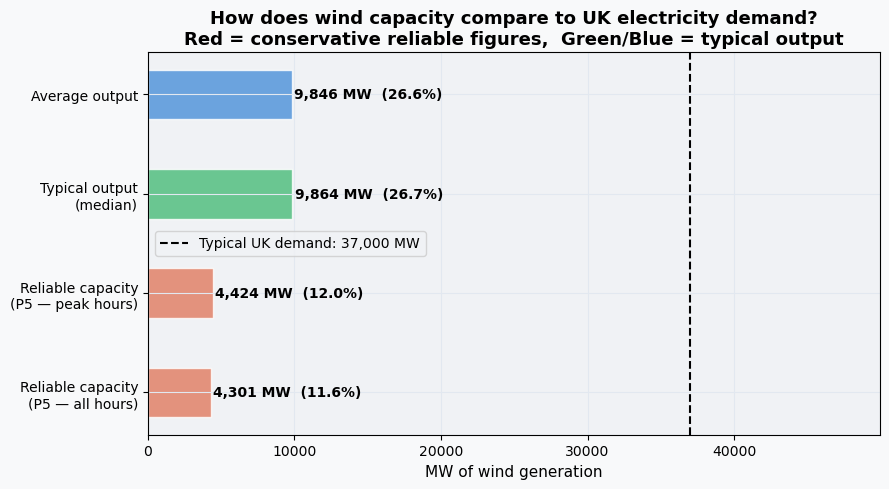

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))

labels = [
    'Reliable capacity\n(P5 — all hours)',
    'Reliable capacity\n(P5 — peak hours)',
    'Typical output\n(median)',
    'Average output',
]
values = [p5_overall, p5_peak, p50_overall, mean_overall]
colors = [RED, RED, GREEN, BLUE]

bars = ax.barh(labels, values, color=colors, alpha=0.8, edgecolor='white', height=0.5)
ax.axvline(UK_TYPICAL_DEMAND, color='black', linewidth=1.5, linestyle='--',
           label=f'Typical UK demand: {UK_TYPICAL_DEMAND:,} MW')

for bar, val in zip(bars, values):
    ax.text(val + 150, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f} MW  ({val/UK_TYPICAL_DEMAND*100:.1f}%)',
            va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('MW of wind generation', fontsize=11)
ax.set_title('How does wind capacity compare to UK electricity demand?\nRed = conservative reliable figures,  Green/Blue = typical output')
ax.set_xlim(0, UK_TYPICAL_DEMAND * 1.35)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fig8_vs_demand.png', dpi=150, bbox_inches='tight')
plt.show()


**What this shows:**

Each bar is a different way of measuring wind output. The black dashed line is UK electricity demand. The gap between any bar and the dashed line is how much other energy sources (gas, nuclear) must always be available to make up the difference.

Conclusion:

Reliably, wind generation can cover 11.6% of UK's electricity 95% of the time. On a typical day however, this value jumps to more than double that capacity. However, most of the energy consumption in the UK still has to be covered by other energy sources like gas, coal and nuclear.

---
## Final Recommendation

In [74]:
conservative = min(p5_overall, p5_peak)

print(f'  Recommended reliable wind capacity: {conservative:,.0f} MW')
print()
print('  Explanation:')
print(f'  - Wind met or exceeded this level 95% of the time in Jan 2024')
print(f'  - It is equal to or less than the all hours and peak hours P5 values,')
print(f'    so it can account for all hours when wind is less reliable')
print(f'  - It also represents {conservative/UK_TYPICAL_DEMAND*100:.1f}% of typical UK electricity demand')
print()
print('  Important caveats:')
print(f'  - From a quick search, January is one of the windiest months in the UK.')
print(f'    Therfore, summer months will have a lower reliable floor.')
print(f'  - The longest low wind period in January was {longest["duration_hours"]:.0f} hours.')
print(f'    Backup sources must be able to cover at least this duration.')
print(f'  - On a typical day wind produces {p50_overall:,.0f} MW ({p50_overall/UK_TYPICAL_DEMAND*100:.0f}% of demand),')
print(f'    which is much more than our conservative floor of {conservative:,.0f} MW.')


  Recommended reliable wind capacity: 4,301 MW

  Explanation:
  - Wind met or exceeded this level 95% of the time in Jan 2024
  - It is equal to or less than the all hours and peak hours P5 values,
    so it can account for all hours when wind is less reliable
  - It also represents 11.6% of typical UK electricity demand

  Important caveats:
  - From a quick search, January is one of the windiest months in the UK.
    Therfore, summer months will have a lower reliable floor.
  - The longest low wind period in January was 10 hours.
    Backup sources must be able to cover at least this duration.
  - On a typical day wind produces 9,864 MW (27% of demand),
    which is much more than our conservative floor of 4,301 MW.
